### 1: Carga y limpieza de datos

Explicación:

* Importación de librerías: Se cargan las librerías esenciales como numpy, pandas, matplotlib, y seaborn para trabajar con los datos y generar gráficos.

* Carga de datos: Se usa np.genfromtxt para cargar los datos desde un archivo CSV, proporcionando el parámetro encoding='utf-8' para manejar caracteres especiales correctamente.

* Renombrado de columnas: Se renombra rooms a bedrooms, baths a bathrooms y sqft a m2 para mayor claridad en el análisis.
Limpieza de la columna address: Se eliminan las cadenas ", Madrid" de la columna address utilizando str.replace().

* Conversión de datos a numérico: Se aseguran de que las columnas price, bedrooms, bathrooms, y m2 sean numéricas, con el parámetro errors='coerce' que convierte los valores no válidos en NaN.

* Visualización de los primeros registros: Se muestra un fragmento de las primeras filas del DataFrame para verificar que los datos se han cargado correctamente.

In [7]:
# Cargar el archivo CSV
df = pd.read_csv('idealista_madrid.csv', encoding='utf-8')

# Eliminar posibles espacios en los nombres de las columnas
df.columns = df.columns.str.strip()

# Renombrar las columnas para mayor claridad
df.rename(columns={
    'price': 'price',
    'rooms': 'bedrooms',
    'baths': 'bathrooms',
    'sqft': 'm2',
    'address': 'address'
}, inplace=True)

# Verificar que las columnas están correctamente cargadas
print(df.columns)  # Comprobar que las columnas están correctas

# Convertir las columnas numéricas a tipo numérico (en caso de que no lo sean)
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'm2']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Ver las primeras filas para confirmar que los datos se han cargado correctamente
print(df.head())

Index(['price', 'bathrooms', 'bedrooms', 'm2', 'address'], dtype='object')
     price  bathrooms  bedrooms   m2     address
0  1920000          3         3  183   Recoletos
1  1995000          3         3  170  Castellana
2  1300000          3         4  270   Hortaleza
3  1650000          3         3  248   Chamartín
4  1590750          3         3  116   Recoletos


### 2: Estadísticas descriptivas iniciales

Explicación:

* Media: Se calcula la media de las columnas numéricas para obtener el valor promedio de cada una.

* Mediana: La mediana es el valor que separa los datos en dos mitades. Es útil especialmente si hay valores extremos que afectan la media.

* Máximo y Mínimo: Se calculan los valores más altos (máximos) y más bajos (mínimos) de cada columna numérica para entender el rango de los datos.

In [8]:
# Calcular estadísticas básicas como media, mediana, máximo y mínimo
print("Media:")
print(df[numeric_cols].mean())
print("\nMediana:")
print(df[numeric_cols].median())
print("\nMáximo y Mínimo:")
print(df[numeric_cols].agg(['max', 'min']))

Media:
price        1.290575e+06
bedrooms     3.474317e+00
bathrooms    2.900546e+00
m2           2.172383e+02
dtype: float64

Mediana:
price        990000.0
bedrooms          3.0
bathrooms         3.0
m2              158.0
dtype: float64

Máximo y Mínimo:
       price  bedrooms  bathrooms    m2
max  8900000        12         12  1768
min   122000         0          1    14


### 3: Visualizaciones iniciales

Explicación:

* Histograma y curva de densidad: Se genera un histograma para cada columna numérica, lo que permite observar la distribución de los datos. Se incluye una curva de densidad (con kde=True) para suavizar y mostrar la distribución de probabilidad.

* Visualización: Cada gráfico incluye un título, etiquetas en los ejes y una leyenda, lo que hace la visualización más clara y fácil de interpretar.

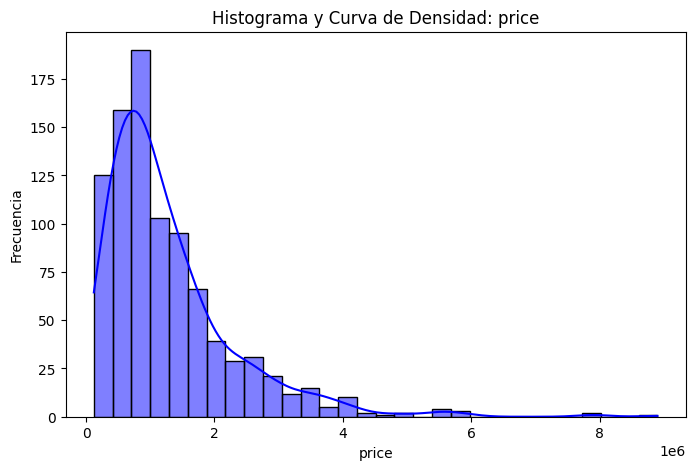

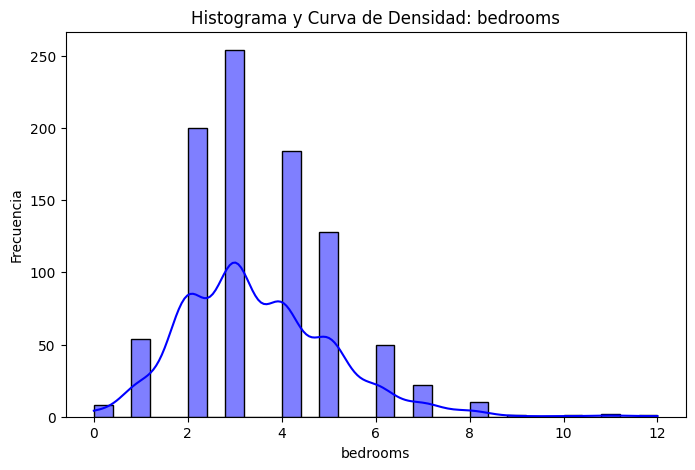

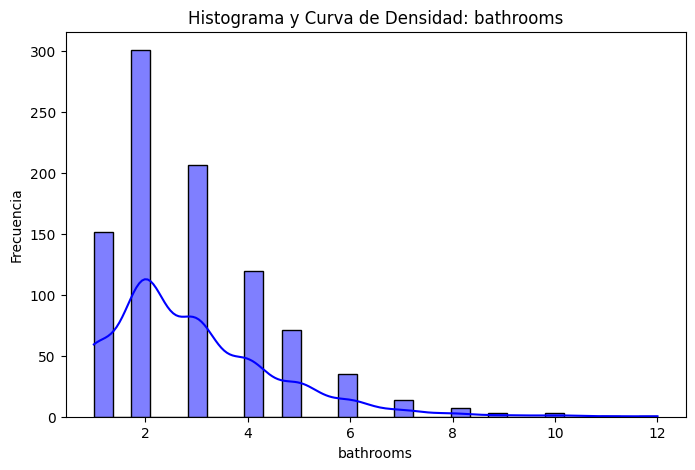

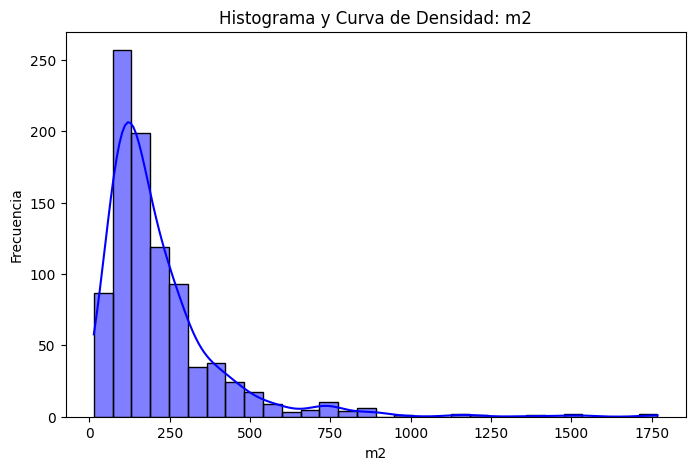

In [9]:
# Generar un histograma y curva de densidad para cada columna numérica
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True, bins=30, color="blue")
    plt.title(f"Histograma y Curva de Densidad: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

### 4: Cuartiles e IQR

Explicación:

* Cuartiles: Los cuartiles dividen los datos en cuatro partes iguales. Q1 es el 25%, Q2 es el 50% (la mediana) y Q3 es el 75%. Estos valores se calculan para cada columna numérica.

* IQR (Rango intercuartílico): El IQR se calcula como la diferencia entre Q3 y Q1. Es útil para detectar valores atípicos (outliers), ya que los valores fuera del rango Q1 - 1.5*IQR y Q3 + 1.5*IQR suelen ser considerados outliers.

In [10]:
# Calcular los cuartiles (Q1, Q2, Q3) y el rango intercuartílico (IQR)
print("\nCuartiles:")
print(df[numeric_cols].quantile([0.25, 0.5, 0.75]))  # 25%, 50%, 75%
print("\nIQR:")
print(df[numeric_cols].apply(lambda x: stats.iqr(x.dropna())))


Cuartiles:
          price  bedrooms  bathrooms     m2
0.25   625000.0       2.0        2.0  104.0
0.50   990000.0       3.0        3.0  158.0
0.75  1650000.0       4.0        4.0  264.0

IQR:
price        1025000.0
bedrooms           2.0
bathrooms          2.0
m2               160.0
dtype: float64


### 5: Filtrado de datos extremos

Explicación:

* Filtrar datos extremos: Se filtran los valores que están en el 20% superior y el 20% inferior en cuanto a precios. Esto ayuda a identificar propiedades que están fuera del rango común y pueden ser consideradas como outliers.

* Visualización de los datos filtrados: Se muestran las primeras filas de las propiedades más caras y más baratas para visualizarlas de manera rápida.

In [11]:
# Filtrar el 20% más caro y más barato
percentile_80 = df['price'].quantile(0.8)
percentile_20 = df['price'].quantile(0.2)

top_20 = df[df['price'] >= percentile_80]
bottom_20 = df[df['price'] <= percentile_20]

# Mostrar las primeras filas de los datos más caros y más baratos
print("20% más caro:")
print(top_20.head())
print("\n20% más barato:")
print(bottom_20.head())

20% más caro:
      price  bathrooms  bedrooms   m2     address
0   1920000          3         3  183   Recoletos
1   1995000          3         3  170  Castellana
6   5700000          5         4  305   Recoletos
7   2190000          4         4  183        Goya
10  3950000          5         4  291   Recoletos

20% más barato:
     price  bathrooms  bedrooms   m2          address
35  470000          2         3   95       Fuencarral
36  475000          2         3  112         Comillas
47  380000          1         3   75  Palos de Moguer
57  325000          1         2   76    Bellas Vistas
64  320000          1         2   52          Palacio


### 6: Moda y dispersión

Explicación:

* Moda: La moda es el valor más frecuente en un conjunto de datos. En este caso, se calcula para la columna address, que podría revelar los barrios más comunes.

* Varianza y desviación estándar: Ambas medidas indican cuán dispersos están los datos respecto a la media. La varianza mide la dispersión en unidades al cuadrado, mientras que la desviación estándar es la raíz cuadrada de la varianza y está en las mismas unidades que los datos.


In [12]:
# Calcular la moda de la columna 'address'
print("\nModa de address:")
print(df['address'].mode())

# Calcular varianza y desviación estándar
print("\nVarianza y Desviación Estándar:")
print(df[numeric_cols].var())  # Varianza
print(df[numeric_cols].std())  # Desviación estándar


Moda de address:
0    Barrio de Salamanca
Name: address, dtype: object

Varianza y Desviación Estándar:
price        1.074623e+12
bedrooms     2.542830e+00
bathrooms    2.645459e+00
m2           3.676646e+04
dtype: float64
price        1.036640e+06
bedrooms     1.594625e+00
bathrooms    1.626487e+00
m2           1.917458e+02
dtype: float64


### 7: Outliers

Explicación:

* Detección de outliers: Se utilizan los límites de Tukey para identificar valores atípicos (outliers). Los valores que están fuera del rango Q1 - 1.5*IQR y Q3 + 1.5*IQR se consideran outliers.

* Visualización: Se utiliza un boxplot para mostrar la distribución de los datos, y los límites inferiores y superiores se marcan con líneas rojas y azules, respectivamente.

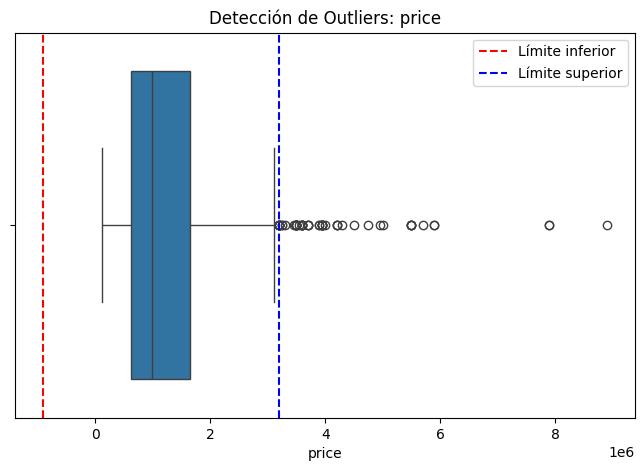

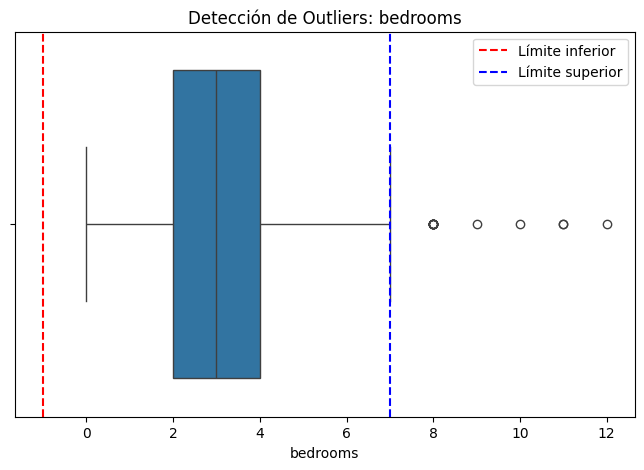

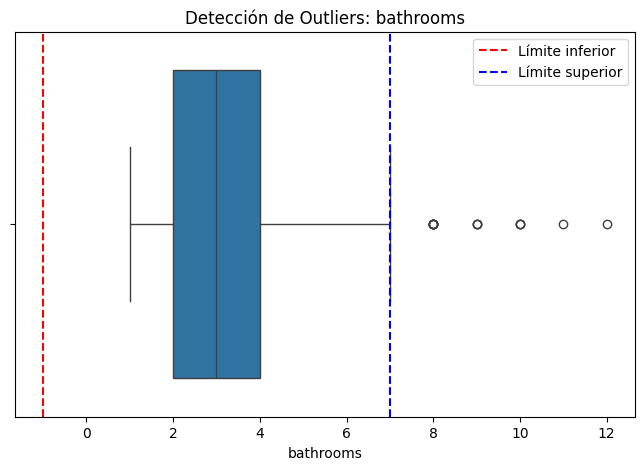

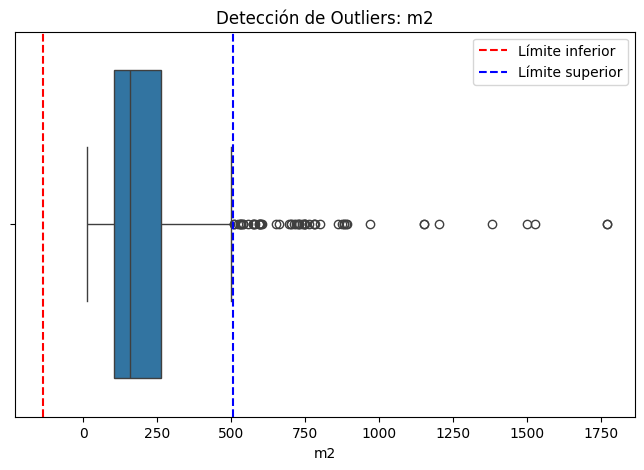

In [13]:
# Detectar y visualizar outliers con los límites de Tukey
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.axvline(lower_bound, color='red', linestyle='--', label='Límite inferior')
    plt.axvline(upper_bound, color='blue', linestyle='--', label='Límite superior')
    plt.title(f"Detección de Outliers: {col}")
    plt.legend()
    plt.show()

### 8: Correlaciones y estandarización

Explicación:

* Matriz de correlación: Calcula cómo se relacionan entre sí las variables numéricas. Se utiliza un heatmap para visualizar las correlaciones. Un valor cercano a 1 o -1 indica una fuerte correlación, mientras que un valor cercano a 0 indica poca o ninguna correlación.

* Estandarización: Se estandarizan las variables numéricas (transformación de media 0 y desviación estándar 1) para que las diferencias de escala no afecten el análisis.

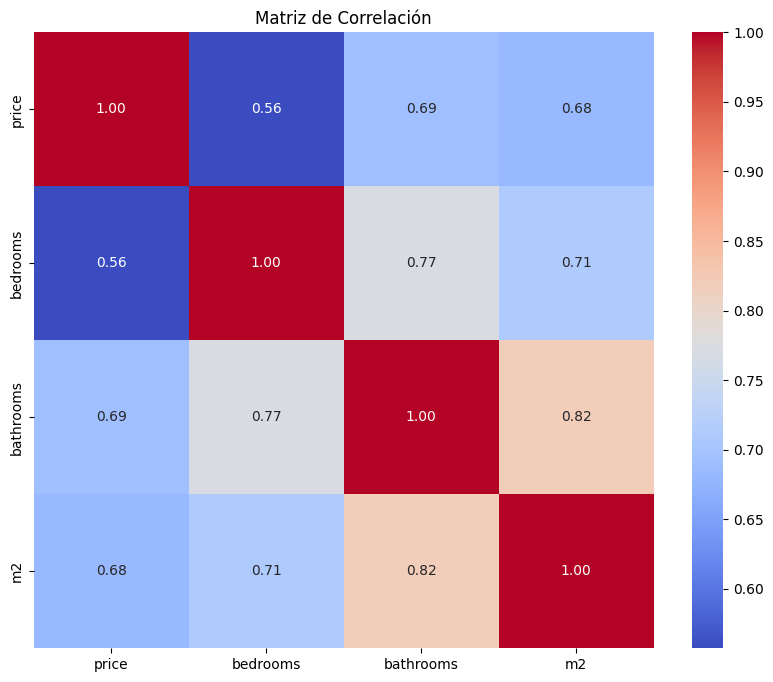


Datos estandarizados (Primeras filas):
      price  bedrooms  bathrooms        m2
0  0.607178 -0.297447   0.061146 -0.178561
1  0.679527 -0.297447   0.061146 -0.246359
2  0.009092  0.329659   0.061146  0.275165
3  0.346721 -0.297447   0.061146  0.160430
4  0.289565 -0.297447   0.061146 -0.527982


In [14]:
# Calcular la matriz de correlación
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

# Estandarización de los datos
df_standardized = df[numeric_cols].apply(lambda x: (x - x.mean()) / x.std())
print("\nDatos estandarizados (Primeras filas):")
print(df_standardized.head())

### 9: Asimetría y curtosis

Explicación:

* Asimetría: Mide la simetría de la distribución de los datos. Un valor cercano a 0 indica simetría, valores positivos indican que la distribución está sesgada hacia la derecha, y valores negativos hacia la izquierda.

* Curtosis: Mide la "altitud" y la "anchura" de la distribución. Un valor positivo indica una distribución más "picuda" que la normal, mientras que un valor negativo indica una distribución más plana.

In [15]:
# Calcular la asimetría y curtosis para cada columna numérica
for col in numeric_cols:
    skewness = stats.skew(df[col].dropna())
    kurtosis = stats.kurtosis(df[col].dropna())
    print(f"Asimetría ({col}): {skewness}")
    print(f"Curtosis ({col}): {kurtosis}")

Asimetría (price): 2.299673447902698
Curtosis (price): 8.547211919938682
Asimetría (bedrooms): 0.8842091486712003
Curtosis (bedrooms): 1.9002632477464054
Asimetría (bathrooms): 1.406223480498869
Curtosis (bathrooms): 3.038919834628685
Asimetría (m2): 3.358506945156488
Curtosis (m2): 17.229111152834456


### 10: Pruebas de hipótesis

Explicación:

* Pruebas de hipótesis: Se realizan pruebas t para comparar la media de los precios entre diferentes grupos de propiedades, como barrios o número de baños. El valor p-value nos indica si existe una diferencia significativa entre los grupos. Un valor de p menor a 0.05 generalmente indica que la diferencia es estadísticamente significativa.

In [20]:
# Mostrar todos los barrios disponibles
print("Barrios disponibles en el dataset:")
barrios = df['address'].unique()  # Obtiene los barrios únicos
print(barrios)

# Pedir al usuario que ingrese los nombres de los barrios a comparar
barrio_x = input("\nIntroduce el nombre del primer barrio (Barrio X): ")
barrio_y = input("Introduce el nombre del segundo barrio (Barrio Y): ")

# Filtrar los datos de los barrios seleccionados
barrio_x_data = df[df['address'] == barrio_x]['price']
barrio_y_data = df[df['address'] == barrio_y]['price']

# Comprobar si hay suficientes datos para los dos barrios
if not barrio_x_data.empty and not barrio_y_data.empty:
    # Realizar la prueba t para comparar las medias de los precios de ambos barrios
    stat, p_value = stats.ttest_ind(barrio_x_data, barrio_y_data, nan_policy='omit')
    print(f"\nContraste de hipótesis (Barrio {barrio_x} vs Barrio {barrio_y}):")
    print(f"Estadístico t: {stat}")
    print(f"p-value: {p_value}")
    
    # Interpretación del resultado
    if p_value < 0.05:
        print("Resultado: La diferencia en los precios entre los barrios es estadísticamente significativa.")
    else:
        print("Resultado: No hay diferencia estadísticamente significativa entre los precios de los barrios.")
else:
    print("\nNo se encontraron suficientes datos para los barrios seleccionados.")

# Comparar propiedades con >= 3 baños y 1-2 baños
baths_3plus = df[df['bathrooms'] >= 3]['price']
baths_1_2 = df[(df['bathrooms'] == 1) | (df['bathrooms'] == 2)]['price']

# Realizar la prueba t para comparar los precios de propiedades con diferentes cantidades de baños
stat, p_value = stats.ttest_ind(baths_3plus, baths_1_2, nan_policy='omit')
print(f"\nContraste de hipótesis (>= 3 baños vs 1-2 baños):")
print(f"Estadístico t: {stat}")
print(f"p-value: {p_value}")

# Interpretación del resultado
if p_value < 0.05:
    print("Resultado: Las propiedades con >= 3 baños son significativamente más caras que las de 1-2 baños.")
else:
    print("Resultado: No hay diferencia significativa en el precio entre las propiedades con >= 3 baños y 1-2 baños.")

Barrios disponibles en el dataset:
['Recoletos' 'Castellana' 'Hortaleza' 'Chamartín' 'Cuatro Caminos' 'Goya'
 'Aravaca' 'Sol' 'Bernabéu-Hispanoamérica' 'Vallehermoso' 'Huertas-Cortes'
 'Chamberí' 'Nueva España' 'Conde Orgaz-Piovera' 'Chueca-Justicia'
 'Argüelles' 'Nuevos Ministerios-Ríos Rosas' 'Centro' 'Moncloa' 'Retiro'
 'Barrio de Salamanca' 'Peñagrande' 'Mirasierra' 'Fuencarral' 'Comillas'
 'Malasaña-Universidad' 'Palos de Moguer' 'San Blas' 'Prosperidad'
 'Bellas Vistas' 'Niño Jesús' 'El Viso' 'Palacio' 'Lista' 'Ciudad Lineal'
 'Lavapiés-Embajadores' 'Salvador' 'Almagro' 'Fuente del Berro'
 'Gaztambide' 'Acacias' 'Arapiles' 'Guindalera' 'Ciudad Universitaria'
 'Puerta del Ángel' 'Ventilla-Almenara' 'Rejas' 'Pau de Carabanchel'
 'Zofío' 'La Paz' 'Valdezarza' 'Pacífico' 'Costillares' 'Trafalgar'
 'Simancas' 'Ibiza' 'Jerónimos' 'Legazpi' 'Palomas' 'Castilla'
 'Pinar del Rey' 'Cuzco-Castillejos' 'San Isidro' 'Opañel' 'Colina'
 'El Cañaveral' 'Valdemarín' 'Tetuán' 'Valdeacederas'
 'Val